# BFS / DFS Applications

각 알고리즘(`dfs`, `bfs`)의 비교 및 활용 데모.

In [1]:
import sys

sys.path.insert(0, '..')

from IPython.display import display

import core.graph as g
from algorithms.graph.bfs import bfs
from algorithms.graph.dfs import dfs

a, b, c, d, e, f = g.vertices('a', 'b', 'c', 'd', 'e', 'f')

g3 = g.UnweightedGraph()
for u, v in [(a, b), (a, c), (b, d), (b, e), (c, f)]:
    g3.add_edge(u, v)

## 9. DFS vs BFS 비교

같은 그래프에 두 알고리즘을 적용해 색 분포 차이를 본다.
- **DFS (chain-based)**: 한 가지를 끝까지 따라가는 패턴이 색으로 드러남
- **BFS (level-based)**: 동심원처럼 퍼지는 패턴이 색으로 드러남

--- DFS (chain-based) ---


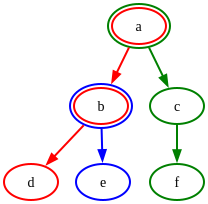

--- BFS (level-based) ---


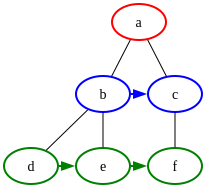

In [2]:
print('--- DFS (chain-based) ---')
display(g3._to_graphviz(highlight=dfs.walks(g3, a)))
print('--- BFS (level-based) ---')
display(g3._to_graphviz(highlight=bfs.levels(g3, a)))

## Q6 (Challenge). DFS vs BFS — same graph, different traversals

```text
0: [1, 2]
1: [0, 3, 4]
2: [0, 5]
3: [1]
4: [1]
5: [2]
Start vertex: 0
```

=== DFS ===
0
1
3
4
2
5


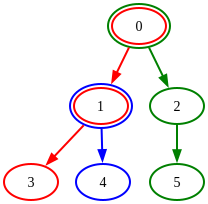


=== BFS ===
0
1
2
3
4
5


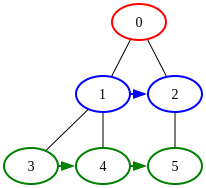

In [3]:
v0, v1, v2, v3, v4, v5 = g.vertices('0', '1', '2', '3', '4', '5')
custom_g = g.UnweightedGraph()
for u, v in [(v0, v1), (v0, v2), (v1, v3), (v1, v4), (v2, v5)]:
    custom_g.add_edge(u, v)

print("=== DFS ===")
for u in dfs.visits(custom_g, v0):
    print(u)
display(custom_g._to_graphviz(highlight=dfs.walks(custom_g, v0)))

print("\n=== BFS ===")
for u in bfs.visits(custom_g, v0):
    print(u)
display(custom_g._to_graphviz(highlight=bfs.levels(custom_g, v0)))

## PS4. Understanding Graph Representations and Structure (15 points)

주어진 문제(Friendship network)를 `lemma` 라이브러리로 해결합니다.

### 1. Draw the graph. You may draw it digitally or by hand and paste it into your PDF.

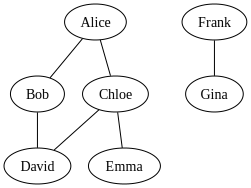

In [4]:
# 정점들을 알파벳 순서대로 생성하여 추가 순서를 보장
alice, bob, chloe, david, emma, frank, gina = g.vertices(
    'Alice', 'Bob', 'Chloe', 'David', 'Emma', 'Frank', 'Gina'
)

ps4_g = g.UnweightedGraph()

# 간선 추가. 인접 리스트가 알파벳 순이 되려면 삽입도 주의.
edges = [
    (alice, bob),
    (alice, chloe),
    (bob, david),
    (chloe, david),
    (chloe, emma),
    (frank, gina)
]
for u, v in edges:
    ps4_g.add_edge(u, v)

from IPython.display import display

display(ps4_g._to_graphviz())

### 2. Write the adjacency list using alphabetical order inside each neighbor list.

In [5]:
print("Adjacency List:")
for label, nbrs in ps4_g._adj.items():
    # 내부 구현상 add_edge 순서대로 저장되지만, 요구사항에 맞춰 알파벳 정렬 후 출력합니다.
    print(f"{label}: {sorted(nbrs)}")

Adjacency List:
Alice: ['Bob', 'Chloe']
Bob: ['Alice', 'David']
Chloe: ['Alice', 'David', 'Emma']
David: ['Bob', 'Chloe']
Emma: ['Chloe']
Frank: ['Gina']
Gina: ['Frank']


### 3. Write the adjacency matrix using the vertex order [Alice, Bob, Chloe, David, Emma, Frank, Gina].

In [6]:
mat = ps4_g.to_adjacency_matrix()
labels = [v.label for v in ps4_g.vertices()]
print("Vertices:", labels)
print("\nAdjacency Matrix:")
for row in mat:
    print(row)

Vertices: ['Alice', 'Bob', 'Chloe', 'David', 'Emma', 'Frank', 'Gina']

Adjacency Matrix:
[0, 1, 1, 0, 0, 0, 0]
[1, 0, 0, 1, 0, 0, 0]
[1, 0, 0, 1, 1, 0, 0]
[0, 1, 1, 0, 0, 0, 0]
[0, 0, 1, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 1, 0]


### 4. Identify the connected components of the graph.

In [7]:
visited = set()
components = []

for v in ps4_g.vertices():
    if v.label not in visited:
        # dfs.visits 로 연결 성분 정점 list 수집
        comp = [u.label for u in dfs.visits(ps4_g, v)]
        visited.update(comp)
        components.append(sorted(comp))

print("Connected Components:")
for i, comp in enumerate(components, 1):
    print(f"Component {i}: {comp}")

Connected Components:
Component 1: ['Alice', 'Bob', 'Chloe', 'David', 'Emma']
Component 2: ['Frank', 'Gina']


### 5. Starting from Alice, write the BFS traversal order and the DFS traversal order.

만약 DFS를 스택으로 구현한다면, 인접 리스트의 **역순(reverse order)**으로 스택에 푸시해야 팝할 때 알파벳 순서대로 먼저 방문하게 됩니다.
(재귀 호출 시에는 리스트 순서대로 순회하면 됩니다.)

In [8]:
bfs_order = [v.label for v in bfs.visits(ps4_g, alice)]
print("BFS Order:", bfs_order)

dfs_order = [v.label for v in dfs.visits(ps4_g, alice)]
print("DFS Order:", dfs_order)

BFS Order: ['Alice', 'Bob', 'Chloe', 'David', 'Emma']
DFS Order: ['Alice', 'Bob', 'David', 'Chloe', 'Emma']


### 6. State whether this graph has a cycle. If yes, identify one cycle.

In [9]:
def find_cycle(graph):
    visited = set()
    def dfs_cycle(v, parent_label):
        visited.add(v.label)
        for nbr_label in graph._adj[v.label]:
            if nbr_label not in visited:
                res = dfs_cycle(graph.get_vertex(nbr_label), v.label)
                if res:
                    return [v.label] + res
            elif nbr_label != parent_label:
                # 이미 방문한 이웃인데 직전 정점이 아니면 사이클
                return [v.label, nbr_label]
        return None

    for v in graph.vertices():
        if v.label not in visited:
            cycle = dfs_cycle(v, None)
            if cycle:
                return cycle
    return None

cycle_path = find_cycle(ps4_g)
if cycle_path:
    print("Yes, the graph has a cycle.")
    print("Cycle found involving:", cycle_path)
else:
    print("No cycle found.")

Yes, the graph has a cycle.
Cycle found involving: ['Alice', 'Bob', 'David', 'Chloe', 'Alice']
